# Redes do tipo Autoencoder

Observação: Este notebook foi concebido com o ambiente ilumpy no JupyterLab.

## Introdução

O presente pergaminho busca mostrar, da maneira mais simples e didática possível o básico sobre uma rede neural do tipo autoencoder. Por isso, não serão adotadas práticas que tornem a rede mais robusta ou eficiente, mas a tornem mais difícil de ler e entender.

Depois dessa discussão superficial, alguns temas mais profundos (imagine água por volta do nível dos tornozelos) serão abordados para que possamos identificar pontos interessantes dessa arquitetura em especial. Dessa forma, teremos aqui estruturado um bom repertório para abordagens mais maduras e complexas das redes autoencoders para aplicações mais críticas.

Ao longo dessa aventura, vamos aprender o porquê de utilizarmos autoencoders, que tipo de problemas eles resolvem, o funcionamento básico de sua arquitetura, passo a passo, e ao final discutir suas aplicações nos diversos ramos da ciência.

## Importações

As bibliotecas que todo mundo ama.

In [1]:
# Python's Essentials
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Torch e Lightning
import torch
import lightning as L
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import os, glob

# Processamento de dados
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from lightning.pytorch.callbacks.early_stopping import EarlyStopping


# semente aleatória fixa!
torch.manual_seed(2112)
np.random.seed(2112)

## Redes autoencoder: onde vivem e o que comem?

Primeiro vamos entender o contexto do uso de encoders em redes neurais. Eles estão presentes em arquiteturas como redes recorrentes e convolucionais, e assim podem ser aplicadas para tarefas como retirar ruído de imagens ou até identificar objetos. Para isso, elas criam máscaras que separam cada pixel de uma imagem em um cluster com base no treinamento em um banco de dados prévio. Por isso, esses frameworks encoder-decoder podem ser exemplos de aprendizado supervisionado.

Os autoencoders, por sua vez, tem uma tarefa diferente, e são um exemplo de aprendizado autossupervisionado. Ou seja, separam os dados em grupos sem que labels existam previamente. Elas identificam padrões e separam os grupos de maneira inédita, sem que esses grupos sejam apresentados a elas. Os autoencoders também podem ser parte de um algoritmo maior, como um "pré-tratamento" de dados.

Como tudo no universo, os autoencoders podem ser explicados com uma metaforazinha engraçada. Imagine que três crianças um tanto espertinhas estão brincando de telefone sem fio. A primeira passa uma mensagem, e a segunda a recebe e a transmite à terceira. Pense que elas trocam frases bem longas.

Poderia ser um jogo inocente, mas a segunda criança tem doutorado em Letras e conhece formas de comunicação tão eficientes quanto misteriosas, e codifica as longas frases em pequenas palavras. Por sorte, a terceira criança está completando seu doutorado em Antropologia e promove um estudo de campo ali mesmo para aprender a língua, simplesmente observando padrões e classificando as palavras em grupos sem qualquer conhecimento prévio. Se as três crianças são competentes o suficiente, a mensagem será transmitida de maneira perfeita, e uma delas terá aprendido um bom bocado sobre essa língua misteriosa patra traduzir mais textos no futuro, ou ao menos classificar mais palavras misteriosas nesses grupos descobertos.

Observe que ao final, as crianças sempre podem conferir se a mensagem foi descoberta e atribuir um score à tentativa, dado que uma delas sabe perfeitamente o que foi dito a princípio e o que foi dito ao final. Sabendo que a criança do meio se comportará de forma parecida na próxima 'iteração' do jogo, a criança decodificadora poderá adaptar-se para melhor compreendê-la. Por isso podemos até dizer que esse é um aprendizado 'autossupervisionado', dado que elas não precisam de nenhum repertório externo ao jogo para avaliar se jogam bem ou mal.

Toda essa seção maluca foi baseada mais ou menos na página da IBM sobre o assunto; [1]

## Sobre Atributos e Targets

### No contexto de autoencoders

Em uma rede como uma MLP comum, nós damos os atributos ao modelo, enquanto o target é a resposta final que ele tenta prever. Para os Autoencoders, o objetivo não é advinhar o rótulo de um ponto. O bichinho é muito mais independente: ele tem que aprender a comprimir e reconstruir a informação original perfeitamente. Logo, o atributo é o seu próprio target (Tchãrãn!). A rede recebe os dados originais na entrada, e depois é forçada a recriar na saída esses exatos mesmos dados. Nesse processo, ela aprende quais são as caracteristicas mais importantes para relacionar os pontos no hiperespaço, que a priori são selecionados por "máscaras", e isso rende muitas aplicações interessantes (que vamos citar mais adiante).

### O que é o MEU dataset?

Pra começar, ele não é meu, mas cedido pela Universidade da Califórnia Irvine em seu repositório para Machine Learning [2]. Ele estuda mudanças no comportamento de camundongos geneticamente normais e camundongos com trissomia quando submetidos à droga memantina em situações de aprendizado. 

As features são níveis de expressão de proteínas, simplesmente. Sabemos também quais ratos portam trissomia e quais são geneticamente normais. Queremos ver se o nosso modelo consegue compactar todas essas informações de proteínas, descartando as menos significativas, mas ainda conseguindo distinguir os grupos de maneira não supervisionada.

Vamos dar início a esse processo extraindo e tratando os nossos dados:

In [2]:
# URL do dataset xlsx no repositório da UCI
df = pd.read_excel('academica_dataset.xls')

# Apaga coluna de ID
if 'MouseID' in df.columns:
    df = df.drop(columns=['MouseID'])

print("Colunas do arquivo:", df.columns.tolist())
print("\nPrimeiras linhas da coluna de Genótipo:")
print(df['Genotype'].value_counts())
print('')
print('Olhá só como ficou:')
df.head()

Colunas do arquivo: ['DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N', 'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pPKCAB_N', 'pRSK_N', 'AKT_N', 'BRAF_N', 'CAMKII_N', 'CREB_N', 'ELK_N', 'ERK_N', 'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N', 'RSK_N', 'APP_N', 'Bcatenin_N', 'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N', 'AMPKA_N', 'NR2B_N', 'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N', 'NUMB_N', 'P70S6_N', 'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N', 'ADARB1_N', 'AcetylH3K9_N', 'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N', 'nNOS_N', 'Tau_N', 'GFAP_N', 'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N', 'pCASP9_N', 'PSD95_N', 'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N', 'SHH_N', 'BAD_N', 'BCL2_N', 'pS6_N', 'pCFOS_N', 'SYP_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N', 'CaNA_N', 'Genotype', 'Treatment', 'Behavior', 'class']

Primeiras linhas da coluna de Genótipo:
Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

Olhá só

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


Depois disso, vamos identificar nossos atributos.

In [3]:
# As colunas de proteínas vão da primeira até a 77
X = df.iloc[:, 0:77] 

# Genótipos associados
y = df['Genotype']

# Máscaras de separação
control_mask = (y == 'Control')
trisomic_mask = (y == 'Ts65Dn')

# Arrancando NaNs e aplicando StandardScaler
imputer = SimpleImputer(strategy='mean') # Preenche dados com a média
scaler = StandardScaler()

X_control_raw = X[control_mask]
X_trisomic_raw = X[trisomic_mask]

# Treinando nos controles e aplicando em todos
X_control_clean = scaler.fit_transform(imputer.fit_transform(X_control_raw)).astype(np.float32)
X_trisomic_clean = scaler.transform(imputer.transform(X_trisomic_raw)).astype(np.float32)

print(f"Controle: {len(X_control_clean)} amostras, Trissômicos: {len(X_trisomic_clean)} amostras.")

Controle: 570 amostras, Trissômicos: 510 amostras.


Aqui, acabamos de criar as tais máscaras de separação. Mas o que elas representam exatamente?

Criamos essas máscaras booleanas para separar os dados de controle dos trissômicos, e treinamos o modelo apenas nos controles. Assim, o Autoencoder foca o seu treinamento na bioquímica de camundongos saudáveis sem ser confundido pelas anomalias dos camundongos trissômicos. Isso ajuda a entender o que torna cada grupo diferente.


In [4]:
# Convertendo para tensores
tensor_control = torch.from_numpy(X_control_clean)

# split de treino e validação
n_train = int(0.75 * len(tensor_control))
n_val = len(tensor_control) - n_train
train_ds, val_ds = random_split(TensorDataset(tensor_control), [n_train, n_val])

# dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# dataloader c geral pra teste final
X_all_combined = np.vstack([X_control_clean, X_trisomic_clean])
y_all_combined = np.hstack([np.zeros(len(X_control_clean)), np.ones(len(X_trisomic_clean))])
all_loader = DataLoader(TensorDataset(torch.from_numpy(X_all_combined)), batch_size=64)

# P.S: Após reflexão, decidi que esse print deve ficar no notebook:
print("Robin, para o Lightningmóvel!")

Robin, para o Lightningmóvel!


## Encoder e Decoder: O navio na garrafa

Eu já falei e falei de "codificar", mas o que isso de fato significa? Nada mais nada menos do que forçarmos essa torrente de dados a passar em um funil. Sim, o que fazemos é uma redução de dimensionalidade: conservamos apenas as dimensões mais essenciais para classificar um ponto como parte de um cluster ou de outro.


O codificador (ou encoder) é um conjunto de camadas sequencialmente menores de neurônios. Cada um deles conta com viés e uma função de ativação, além dos pesos que os conectam com as camadas anterior e posterior.

Entre o codificador e o decodificador, existe esse lugar abstrato chamado "bottleneck" ou gargalo em português. Nesse meio são descobertas as variáveis latentes, que juntas compõem o **espaço latente**.

Esse espaço é o ponto mais estreito do autoencoder, onde as várias variáveis que damos a princípio são abstraídas em relações geométricas que a rede descobre. São características latentes pois estão escondidas em dados brutos, e são percebidas de maneira não linear em meio às funções de ativação. Das 77 variáveis que são as proteínas, o nosso encoder compacta para 32 dimensões. Depois, o espaço latente é habitado em 10 dimensões, passando por uma MLP comum, até que haja a descompactação do decoder para as 77 proteínas originais.


O decodificador, por fim, tenta retomar a dimensionalidade original aumentando o número de neurônios com camada, completando esse formato de "ampulheta" para o grafo computacional.

Aí você pergunta: "Ai, mas qual é o problema de usar PCA?", e eu te digo, infeliz, que a análise de componentes principais não identifica relações não-lineares. Os autoencoders são repletos de funções não-lineares como a ReLU e conseguem um desempenho muito melhor nessa compactação dependendo do caso. Essa é uma das grandes vantagens de usar redes neurais com funções de ativação não lineares, e se não fosse isso, nós estaríamos fazendo meras REGRESSÕES LINEARES!

No espaço latente, começamos com uma camada linear pra receber os dados. Depois disso, escolhi a função **Tanh** para passar pelo espaço latente. Sem ela, o bottleneck seria inteiramente linear, que deixaria o meu algoritmo bem parecido com o que a PCA já faz. A função tangente hiperbólica limita os valores latentes ao intervalo (-1, 1), o que também ajuda a regularizar o espaço e facilita a separação geométrica dos grupos.

Depois, você vai reparar que a camada de saída não tem função de ativação. MAS CAIO, POR QUE???? Calma, calma, nossos dados foram normalizados np StandardScaler, que produz valores de qualquer sinal e magnitude. Uma sigmoide ou ReLU na saída podia distorcer a reconstrução. De qualquer forma, já passamos tudo por muitas funções de ativação não-lineares.

In [5]:
class ProteinaAutoencoder(L.LightningModule):
    def __init__(self, input_dim=77, latent_dim=10):
        super().__init__()
        # Salva parâmetros iniciais
        self.save_hyperparameters()
        
        # O ENCODER
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.Tanh()
        )
        
        # O DECODER
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
        
        # Função de Perda
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def encode(self, x):
        """Retorna só a representação latente. Útil pra visualização!"""
        return self.encoder(x)

    def training_step(self, batch, batch_idx):
        x = batch[0]
        x_hat = self(x)
        loss = self.loss_fn(x_hat, x)
        
        self.log("train_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch[0]
        x_hat = self(x)
        val_loss = self.loss_fn(x_hat, x)
        self.log("val_loss", val_loss, prog_bar=True, on_epoch=True, on_step=False)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=1e-3)

Observe que a diferença para uma MLP, é que as Multilayer Perceptrons precisam de dados de entrada e labels, enquanto aqui só precisamos de dados de entrada. A saída é a tentativa de uma mera reconstrução desses dados de entrada a partir de uma versão reduzida, compactada. É como ouvir os best-hits do Led Zeppelin e tentar fazer uma banda cover com direito a lado B. É uma tarefa difícil, mas com bastante tempo e processamento, um músico decente e bem estruturado pode conseguir fazer algo interessante. Podemos medir a perda usando uma função MSE para comparar os dados de saída e os de entrada.

Agora que temos uma arquitetura razoavelmente bem-nutrida, preciso garantir que o treinamento também esteja robusto. Aqui, uso Early Stopping para monitorar a perda de validação e parar o treino automaticamente quando passo algumas épocas sem melhorar desempenho e minha paciência acaba (sim, meio que literalmente).

In [6]:
# Instanciando o modelo
modelo = ProteinaAutoencoder(input_dim=77, latent_dim=10)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
    verbose=True
)

# Configurando o treinador
trainer = L.Trainer(
    max_epochs=100,
    accelerator="cpu",
    devices="1",
    callbacks=[early_stop],
    log_every_n_steps=1,
    enable_model_summary=True
)

# Treino
trainer.fit(modelo, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\caio25001\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, w

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Sequential │  2.8 K │ train │     0 │
│ 1 │ decoder │ Sequential │  2.9 K │ train │     0 │
│ 2 │ loss_fn │ MSELoss    │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 5.7 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.7 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\caio25001\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\caio25001\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connect
or.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value
of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.

C:\Users\caio25001\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connect
or.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.

Metric val_loss improved. New best score: 0.949
Metric val_loss improved by 0.032 >= min_delta = 0.0. New best score: 0.918
Metric val_loss improved by 0.053 >= min_delta = 0.0. New best score: 0.865
Metric val_loss improved by 0.069 >= min_delta = 0.0. New best score: 0.796
Metric val_loss improved by 0.075 >= min_delta = 0.0. New best score: 0.721
Metric val_loss improved by 0.067 >= min_delta = 0.0. New best score: 0.654
Metric val_loss improved by 0.051 >= min_delta = 0.0. New best score: 0.604
Metric val_loss improved by 0.036 >= min_delta = 0.0. New best score: 0.568
Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 0.540
Metric val_loss improved by 0.023 >= min_delta = 0.0. New best score: 0.517
Metric val_loss improved by 0.019 >= min_delta = 0.0. New best score: 0.498
Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 0.482
Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 0.468
Metric val_loss improved by 0.013 >= min

## Curva de Aprendizado

Antes de partir para a avaliação, vamos olhar para o que aconteceu durante o treino e prestar atenção em cortar o processo quando observamos overfitting.

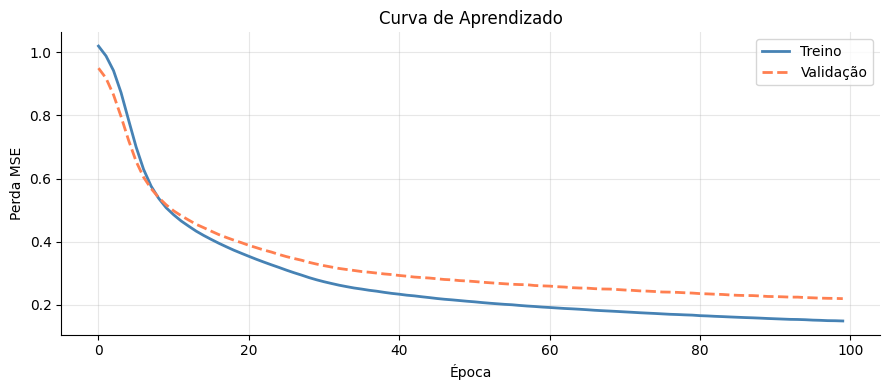

O treino parou na época 100.


In [7]:
csv_files = glob.glob('lightning_logs/version_*/metrics.csv')
csv_file = sorted(csv_files)[-1]

metricas = pd.read_csv(csv_file)

train_metrics = metricas[metricas['train_loss'].notna()][['epoch', 'train_loss']]
val_metrics   = metricas[metricas['val_loss'].notna()][['epoch', 'val_loss']]

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(train_metrics['epoch'], train_metrics['train_loss'],
        label='Treino', color='steelblue', linewidth=2)
ax.plot(val_metrics['epoch'], val_metrics['val_loss'],
        label='Validação', color='coral', linewidth=2, linestyle='--')

ax.set_xlabel('Época')
ax.set_ylabel('Perda MSE')
ax.set_title('Curva de Aprendizado')
ax.legend()
ax.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"O treino parou na época {int(metricas['epoch'].max()) + 1}.")

## Avaliação do Modelo

Até agora, só usamos a máscara de camundongos controle para treinar o modelo. Mas nos nossos dados de avaliação, vamos passar camundongos de todos os tipos. Para cada camundongo, a rede tenta reconstruir as 77 proteínas targets; a diferença entre a entrada real "$x$" e o que a rede conseguiu recriar ($x'$) é calculada através do MSE. Podemos devolver a rotulação original a cada um desses erros e organizá-los em um dataframe. É a partir desses valores que descobriremos se a rede consegue diferenciar os camundongos trissômicos, já que ela deve apresentar erros significativamente maiores para eles do que para o grupo controle. Quem pensou nisso realmente tava pensando com força. Uau.

In [8]:
modelo.eval()
erros = []

with torch.no_grad():
    for batch in all_loader:
        x = batch[0]
        x_eval = modelo(x)
        # MSE
        erro_individual = torch.mean((x - x_eval)**2, dim=1)
        erros.extend(erro_individual.tolist())

# Criando o dataframe
labels = ['Control'] * len(X_control_clean) + ['Ts65Dn'] * len(X_trisomic_clean)

df_resultados = pd.DataFrame({
    'Genotype': labels,
    'Erro_Reconstrucao': erros
})

df_resultados.head()

,Genotype,Erro_Reconstrucao
0,Control,0.187502
1,Control,0.172973
2,Control,0.198998
3,Control,0.090165
4,Control,0.099894


Precisamos definir um limiar de detecção porque nem todos os ratos saudáveis tem a saúde linda, perfeita e maravilhosa. Precisamos de um limiar razoável que permita distinguir um grupo variado de indivíduos saudáveis dos indivíduos afetados pela trissomia.

In [9]:
# erros do grupo controle
erros_controle = df_resultados[df_resultados['Genotype'] == 'Control']['Erro_Reconstrucao']

# Definindo threshold em 95%
limiar = np.percentile(erros_controle, 95)

print(f"Limiar de detecção (95%): {limiar:.4f}")

Limiar de detecção (95%): 0.3846


Agora só vamos descobrir nossa taxa de acerto e entender como tudo isso funciona.

In [10]:
# Identifica quem passou o threshold
df_resultados['Anomalia_Detectada'] = df_resultados['Erro_Reconstrucao'] > limiar

# Contagem
total_ts = len(X_trisomic_clean)
acertos_ts = df_resultados[(df_resultados['Genotype'] == 'Ts65Dn') & 
                           (df_resultados['Anomalia_Detectada'])].shape[0]

print(f"Resultado da Experiência:")
print(f"Dos {total_ts} camundongos trissômicos, o modelo identificou {acertos_ts} como anomalias.")
print(f"Taxa de acerto (Recall): {100 * acertos_ts/total_ts:.2f}%")

Resultado da Experiência:
Dos 510 camundongos trissômicos, o modelo identificou 242 como anomalias.
Taxa de acerto (Recall): 47.45%


Essa taxa de acerto sofrida nos revela que a assinatura da trissomia no proteoma dos ratos é bem discreta. Não é tão fácil distinguir ratos normais para essa condição dos afetados apenas pelas proteínas que eles expressam. O baixo recall também é resultado de um threshold (ou limiar) bem exigente que escolhi. Ainda assim, prefiro manter esse valor alto para ter menos falsos positivos para a condição. Para um algoritmo simples, até que o modelo resultante teve um desempenho razoável.

Vamos olhar para outras métricas para entender melhor o que aconteceu. Se o modelo for bom, a gente esperaria que as distribuições sejam distintas, com os trissômicos deslocados para a direita.

C:\Users\caio25001\AppData\Local\Temp\ipykernel_13344\2467403500.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_resultados, x='Genotype', y='Erro_Reconstrucao',


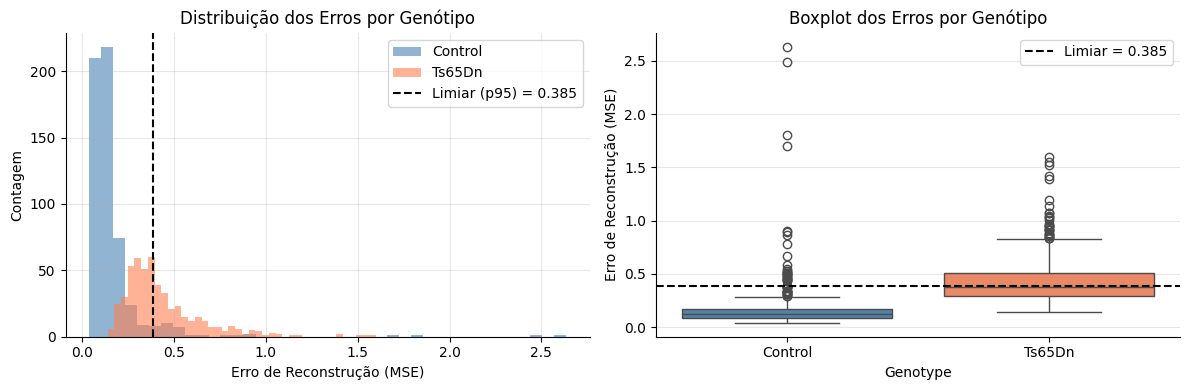

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
for genotype, color in [('Control', 'steelblue'), ('Ts65Dn', 'coral')]:
    subset = df_resultados[df_resultados['Genotype'] == genotype]['Erro_Reconstrucao']
    axes[0].hist(subset, bins=40, alpha=0.6, label=genotype, color=color, edgecolor='none')

axes[0].axvline(limiar, color='black', linestyle='--', linewidth=1.5, label=f'Limiar (p95) = {limiar:.3f}')
axes[0].set_xlabel('Erro de Reconstrução (MSE)')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição dos Erros por Genótipo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
sns.boxplot(data=df_resultados, x='Genotype', y='Erro_Reconstrucao',
            palette={'Control': 'steelblue', 'Ts65Dn': 'coral'}, ax=axes[1])
axes[1].axhline(limiar, color='black', linestyle='--', linewidth=1.5, label=f'Limiar = {limiar:.3f}')
axes[1].set_title('Boxplot dos Erros por Genótipo')
axes[1].set_ylabel('Erro de Reconstrução (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

sns.despine()
plt.tight_layout()
plt.show()

### Métricassss!

Vamos analisar as métricas do nosso modelo e ver se eu consigo tirar uma história deles.

In [12]:
tp = df_resultados[(df_resultados['Genotype'] == 'Ts65Dn') & (df_resultados['Anomalia_Detectada'])].shape[0]
fp = df_resultados[(df_resultados['Genotype'] == 'Control') & (df_resultados['Anomalia_Detectada'])].shape[0]
fn = df_resultados[(df_resultados['Genotype'] == 'Ts65Dn') & (~df_resultados['Anomalia_Detectada'])].shape[0]
tn = df_resultados[(df_resultados['Genotype'] == 'Control') & (~df_resultados['Anomalia_Detectada'])].shape[0]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 40)
print(f"{'Métrica':<20} {'Valor':>10}")
print("=" * 40)
print(f"{'Verdadeiros Positivos':<20} {tp:>10}")
print(f"{'Falsos Positivos':<20} {fp:>10}")
print(f"{'Falsos Negativos':<20} {fn:>10}")
print(f"{'Verdadeiros Negativos':<20} {tn:>10}")
print("-" * 40)
print(f"{'Precisão':<20} {precision:>10.2%}")
print(f"{'Recall':<20} {recall:>10.2%}")
print(f"{'F1-Score':<20} {f1:>10.2%}")
print("=" * 40)
print("OBS:")
print("FP = erro tipo 1")
print("FN = erro tipo 2")

Métrica                   Valor
Verdadeiros Positivos        242
Falsos Positivos             29
Falsos Negativos            268
Verdadeiros Negativos        541
----------------------------------------
Precisão                 89.30%
Recall                   47.45%
F1-Score                 61.97%
OBS:
FP = erro tipo 1
FN = erro tipo 2


### Visualizando o Espaço Latente

O modelo comprimiu 77 proteínas em 10 dimensões no espaço latente. O que mais acontece com os pobres ratinhos nessa dimensão sombria?

Vamos plotar isso em 2 dimensões pra ficar mais visualizável, e pra isso.... usamos PCA. Por questões de visualização, juro! MAS, se pudermos observar uma separação entre os grupos aqui, isso pode significar que o autoencoder aprendeu algo de verdade sobre a bioquímica dos ratos de maneira AUTOSSUPERVISIONADA!

Variância explicada pelos 2 componentes principais: 45.1%


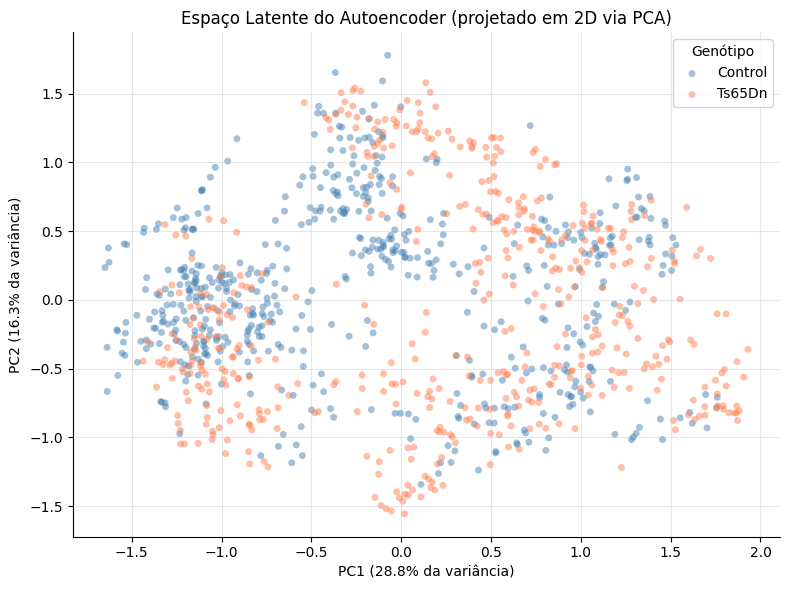

In [13]:
modelo.eval()
latentes = []

with torch.no_grad():
    for batch in all_loader:
        x = batch[0]
        z = modelo.encode(x)
        latentes.extend(z.numpy())

latentes = np.array(latentes)
rotulos  = np.array(['Control'] * len(X_control_clean) + ['Ts65Dn'] * len(X_trisomic_clean))

#PCA de 10 para 2 dimensões
pca = PCA(n_components=2)
latentes_2d = pca.fit_transform(latentes)

variancia_explicada = pca.explained_variance_ratio_.sum() * 100
print(f"Variância explicada pelos 2 componentes principais: {variancia_explicada:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cores = {'Control': 'steelblue', 'Ts65Dn': 'coral'}
for genotype in ['Control', 'Ts65Dn']:
    mask = rotulos == genotype
    ax.scatter(latentes_2d[mask, 0], latentes_2d[mask, 1],
               c=cores[genotype], label=genotype, alpha=0.5, s=25, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
ax.set_title('Espaço Latente do Autoencoder (projetado em 2D via PCA)')
ax.legend(title='Genótipo')
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Se você consegue ver uma separação de dois grupos no gráfico acima, parabéns, porque eu não consegui. Essas "núvens" se sobrepõem quase qye completamente, e infelizmente para nós mas felizmente para a lógica, isso concorda com o recall baixo. Apesar das diferenças fisiológicas e comportamentais, o sinal proteico da trissomia em camundongos é sutil demais para nosso algoritmo simples.

## Reflexão: para que serve isso?

Esses autoencoders apresentam muitas aplicações científicas interessantíssimas, como compactação de dados e eliminação de ruído. Como foi comentado, os autoencoders são uma alternativa não linear à PCA, e podem servir dados de entrada para uma rede neural maior como meio de economizar processamento. Elas podem compor sistemas que identificam outliers de maneira bem robusta, sem treinamento prévio. Por meio da compressão, podem ajudar a diminuir ou eliminar ruído de áudio e imagens, além de poderem reconstruir uma imagem seguindo a lógica inversa, complementando-a com camadas extras.

## Bibliografia

[1] Página da IBM sobre autoencoders: https://www.ibm.com/br-pt/think/topics/autoencoder

[2] Origem do meu dataset: Higuera, Clara, Katheleen Gardiner, and Krzysztof Cios. "Mice Protein Expression." UCI Machine Learning Repository, 2015, https://doi.org/10.24432/C50S3Z.

Deep Leaning Book
Capítulo 58: https://www.deeplearningbook.com.br/introducao-aos-autoencoders/

Aulas e material de aula do curso de Redes Neurais e Algoritmos Genéticos.